# Berkshire Hathaway Class B (BRK-B) — 20-Year Historical Data
Data sourced from Yahoo Finance via `yfinance`.

In [1]:
# Upgrade pip and install/update dependencies
%pip install --upgrade pip yfinance matplotlib pandas statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd

# Download 20 years of monthly BRK-B data
ticker = yf.Ticker('BRK-B')
df = ticker.history(period='20y', interval='1mo', actions=True)

# Clean up timezone info for display
df.index = df.index.tz_localize(None)

# Drop action columns that never occurred
for col in ['Dividends', 'Stock Splits']:
    if col in df.columns and df[col].sum() == 0:
        df.drop(columns=[col], inplace=True)
        print(f'Dropped "{col}" — no events in 20-year period.')

print(f'\nRecords fetched: {len(df)}')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Dropped "Dividends" — no events in 20-year period.

Records fetched: 240
Date range: 2006-04-01 to 2026-03-01
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Stock Splits']


,Open,High,Low,Close,Volume,Stock Splits
Date,,,,,,
2006-04-01,60.200001,60.500000,56.779999,59.040001,20125000,0.0
2006-05-01,59.160000,61.980000,58.200001,61.380001,19995000,0.0
2006-06-01,61.459999,61.779999,59.630001,60.860001,16290000,0.0
2006-07-01,61.299999,61.439999,59.560001,60.939999,13740000,0.0
2006-08-01,60.939999,64.580002,60.660000,64.070000,15875000,0.0
2006-09-01,63.860001,64.760002,61.779999,63.480000,12160000,0.0
2006-10-01,63.400002,70.459999,63.299999,70.300003,17140000,0.0
2006-11-01,70.199997,72.559998,68.900002,71.099998,17125000,0.0
2006-12-01,71.099998,76.500000,70.400002,73.320000,18400000,0.0


In [3]:
# Summary statistics
df.describe().round(2)

,Open,High,Low,Close,Volume,Stock Splits
count,240.00,240.00,240.00,240.00,2.400000e+02,240.00
mean,188.50,196.16,181.04,190.14,8.056322e+07,0.21
std,127.01,131.73,121.78,128.30,4.899173e+07,3.23
min,47.70,59.78,44.82,51.28,1.054000e+07,0.00
25%,81.49,84.36,78.99,81.63,6.240048e+07,0.00
50%,144.46,148.30,141.85,144.40,7.900075e+07,0.00
75%,249.08,270.07,246.12,258.36,9.481180e+07,0.00
max,531.88,542.07,500.19,533.25,5.650577e+08,50.00


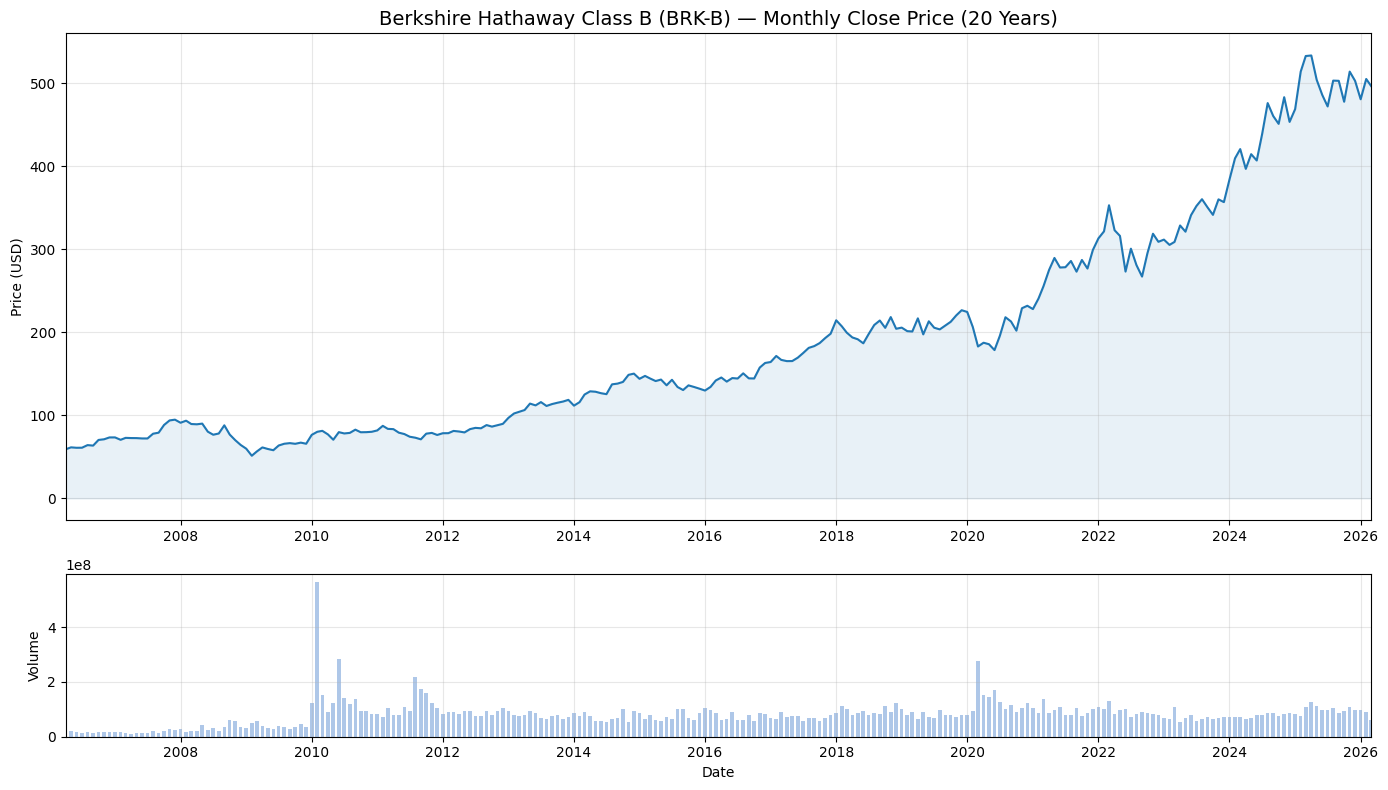

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Price chart
ax1.plot(df.index, df['Close'], color='#1f77b4', linewidth=1.5)
ax1.fill_between(df.index, df['Close'], alpha=0.1, color='#1f77b4')
ax1.set_title('Berkshire Hathaway Class B (BRK-B) — Monthly Close Price (20 Years)', fontsize=14)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(df.index[0], df.index[-1])

# Volume chart
ax2.bar(df.index, df['Volume'], color='#aec7e8', width=20)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(df.index[0], df.index[-1])

plt.tight_layout()
plt.show()

In [5]:
# Monthly returns
df['Monthly Return'] = df['Close'].pct_change() * 100  # as percentage

print(f'Average monthly return: {df["Monthly Return"].mean():.2f}%')
print(f'Best month:  {df["Monthly Return"].max():.2f}% ({df["Monthly Return"].idxmax().strftime("%b %Y")})')
print(f'Worst month: {df["Monthly Return"].min():.2f}% ({df["Monthly Return"].idxmin().strftime("%b %Y")})')
print(f'Positive months: {(df["Monthly Return"] > 0).sum()} / {df["Monthly Return"].notna().sum()}')

df[['Close', 'Monthly Return']].dropna().round(2)

Average monthly return: 1.03%
Best month:  16.30% (Jan 2010)
Worst month: -14.22% (Feb 2009)
Positive months: 134 / 239


,Close,Monthly Return
Date,,
2006-05-01,61.38,3.96
2006-06-01,60.86,-0.85
2006-07-01,60.94,0.13
2006-08-01,64.07,5.14
2006-09-01,63.48,-0.92
...,...,...
2025-11-01,513.81,7.60
2025-12-01,502.65,-2.17
2026-01-01,480.53,-4.40


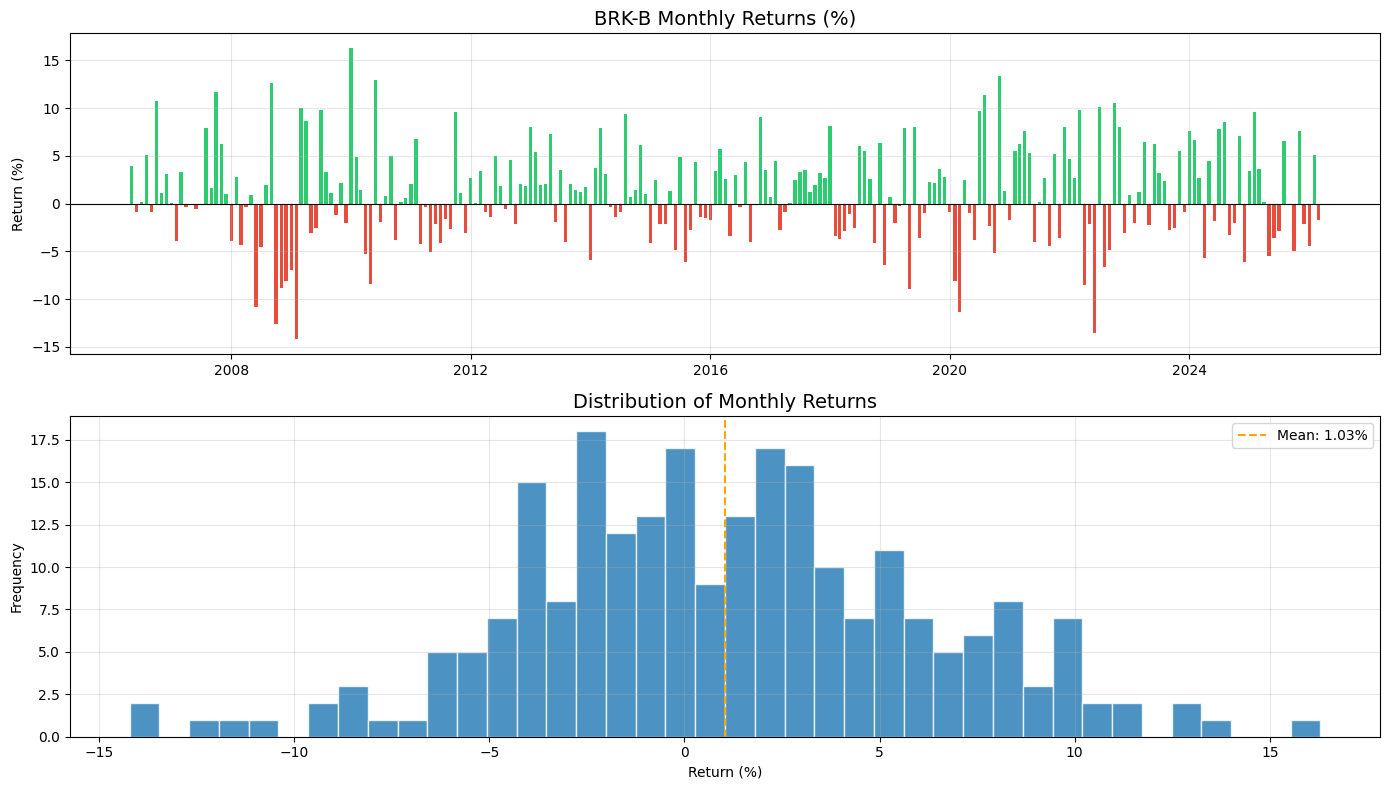

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Bar chart: monthly returns colored green/red
returns = df['Monthly Return'].dropna()
colors = ['#2ecc71' if r >= 0 else '#e74c3c' for r in returns]
ax1.bar(returns.index, returns, color=colors, width=20)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('BRK-B Monthly Returns (%)', fontsize=14)
ax1.set_ylabel('Return (%)')
ax1.grid(True, alpha=0.3)

# Histogram of return distribution
ax2.hist(returns, bins=40, color='#1f77b4', edgecolor='white', alpha=0.8)
ax2.axvline(returns.mean(), color='orange', linewidth=1.5, linestyle='--', label=f'Mean: {returns.mean():.2f}%')
ax2.set_title('Distribution of Monthly Returns', fontsize=14)
ax2.set_xlabel('Return (%)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Full data table
pd.set_option('display.max_rows', 300)
df.round(4)

,Open,High,Low,Close,Volume,Stock Splits,Monthly Return
Date,,,,,,,
2006-04-01,60.20,60.50,56.78,59.04,20125000,0.0,NaN
2006-05-01,59.16,61.98,58.20,61.38,19995000,0.0,3.9634
2006-06-01,61.46,61.78,59.63,60.86,16290000,0.0,-0.8472
2006-07-01,61.30,61.44,59.56,60.94,13740000,0.0,0.1314
2006-08-01,60.94,64.58,60.66,64.07,15875000,0.0,5.1362
2006-09-01,63.86,64.76,61.78,63.48,12160000,0.0,-0.9209
2006-10-01,63.40,70.46,63.30,70.30,17140000,0.0,10.7435
2006-11-01,70.20,72.56,68.90,71.10,17125000,0.0,1.1380
2006-12-01,71.10,76.50,70.40,73.32,18400000,0.0,3.1224


## Fama-French 3-Factor Regression
Regresses BRK-B excess returns on the three Fama-French factors:
- **Mkt-RF**: Market excess return (market risk premium)
- **SMB**: Small Minus Big (size factor)
- **HML**: High Minus Low (value factor)

Model: `R_i - R_f = α + β₁(Mkt-RF) + β₂(SMB) + β₃(HML) + ε`

In [8]:
import io, zipfile, requests
import statsmodels.api as sm

# Download Fama-French 3 factors directly from Ken French's data library
url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip'
r = requests.get(url, timeout=30)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    with z.open(z.namelist()[0]) as f:
        raw = f.read().decode('utf-8')

# Parse CSV — skip header rows, stop at annual section
lines = raw.splitlines()
start = next(i for i, l in enumerate(lines) if l.strip().startswith('19') or l.strip().startswith('20'))
end = next(i for i, l in enumerate(lines) if i > start and l.strip() == '')
ff3 = pd.read_csv(io.StringIO('\n'.join(lines[start:end])), header=None,
                  names=['Date', 'Mkt-RF', 'SMB', 'HML', 'RF'])
ff3['Date'] = pd.to_datetime(ff3['Date'].astype(str), format='%Y%m')
ff3.set_index('Date', inplace=True)
ff3 = ff3.apply(pd.to_numeric, errors='coerce').dropna()

# Align BRK-B monthly returns with FF3 (both in %)
brk_returns = df['Monthly Return'].dropna().copy()
brk_returns.index = brk_returns.index.to_period('M').to_timestamp()

merged = pd.concat([brk_returns, ff3], axis=1, join='inner')
merged.columns = ['BRK-B', 'Mkt-RF', 'SMB', 'HML', 'RF']
merged['Excess Return'] = merged['BRK-B'] - merged['RF']

print(f'Regression period: {merged.index[0].date()} to {merged.index[-1].date()}')
print(f'Observations: {len(merged)}')
merged.head()

Regression period: 2006-05-01 to 2026-01-01
Observations: 237


,BRK-B,Mkt-RF,SMB,HML,RF,Excess Return
Date,,,,,,
2006-05-01,3.963415,-3.56,-3.01,2.38,0.43,3.533415
2006-06-01,-0.847182,-0.35,-0.35,0.85,0.40,-1.247182
2006-07-01,0.131446,-0.77,-3.95,2.62,0.40,-0.268554
2006-08-01,5.136201,2.03,0.99,-1.95,0.42,4.716201
2006-09-01,-0.920868,1.84,-1.30,0.06,0.41,-1.330868


In [9]:
# OLS regression: BRK-B excess return ~ Mkt-RF + SMB + HML
X = sm.add_constant(merged[['Mkt-RF', 'SMB', 'HML']])
y = merged['Excess Return']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Excess Return   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     57.72
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           6.14e-28
Time:                        13:36:08   Log-Likelihood:                -659.01
No. Observations:                 237   AIC:                             1326.
Df Residuals:                     233   BIC:                             1340.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3131      0.262      1.197      0.2

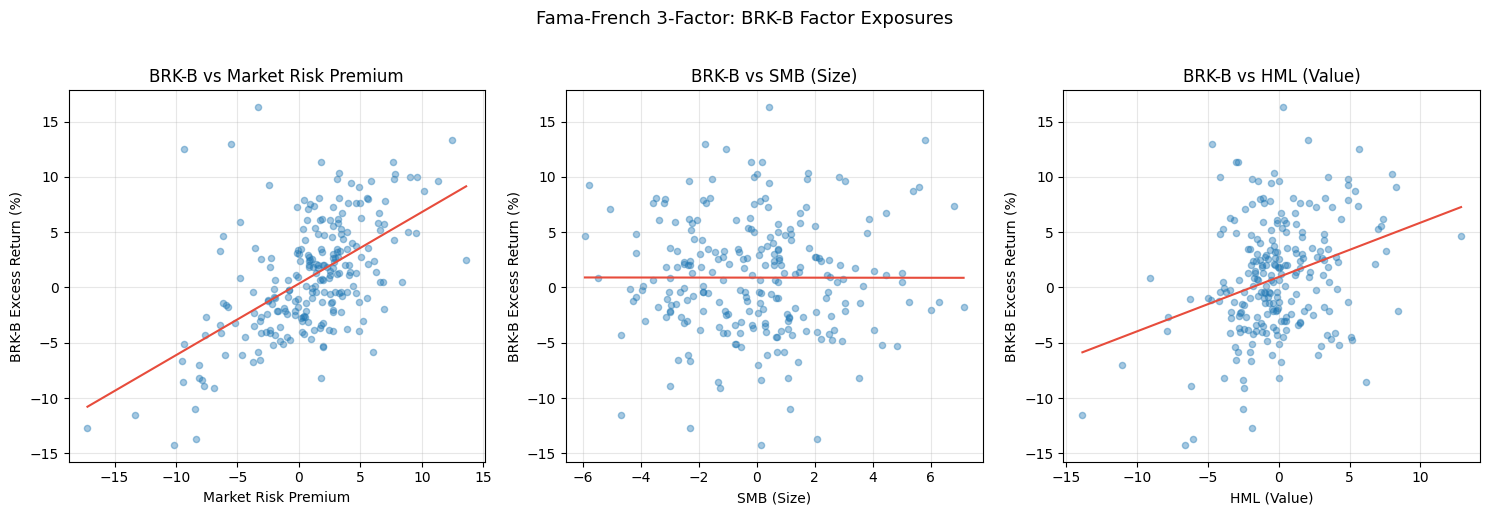


Alpha (annualized): 3.76%
Market Beta:        0.6964
SMB Beta:           -0.4794
HML Beta:           0.4049
R-squared:          0.4263


In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

factors = ['Mkt-RF', 'SMB', 'HML']
labels = ['Market Risk Premium', 'SMB (Size)', 'HML (Value)']

for ax, factor, label in zip(axes, factors, labels):
    ax.scatter(merged[factor], merged['Excess Return'], alpha=0.4, s=20, color='#1f77b4')
    # Fit line
    m, b = np.polyfit(merged[factor], merged['Excess Return'], 1)
    x_line = np.linspace(merged[factor].min(), merged[factor].max(), 100)
    ax.plot(x_line, m * x_line + b, color='#e74c3c', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel('BRK-B Excess Return (%)')
    ax.set_title(f'BRK-B vs {label}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Fama-French 3-Factor: BRK-B Factor Exposures', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print key results
print(f"\nAlpha (annualized): {model.params['const'] * 12:.2f}%")
print(f"Market Beta:        {model.params['Mkt-RF']:.4f}")
print(f"SMB Beta:           {model.params['SMB']:.4f}")
print(f"HML Beta:           {model.params['HML']:.4f}")
print(f"R-squared:          {model.rsquared:.4f}")

## Fama-French 5-Factor Regression
Adds two factors to the 3-factor model:
- **RMW**: Robust Minus Weak (profitability — do companies Buffett buys earn more?)
- **CMA**: Conservative Minus Aggressive (investment — does Buffett favor low-capex, capital-light businesses?)

Model: `R_i - R_f = α + β₁(Mkt-RF) + β₂(SMB) + β₃(HML) + β₄(RMW) + β₅(CMA) + ε`

In [11]:
# Download Fama-French 5 factors directly from Ken French's data library
url5 = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'
r5 = requests.get(url5, timeout=30)
with zipfile.ZipFile(io.BytesIO(r5.content)) as z:
    with z.open(z.namelist()[0]) as f:
        raw5 = f.read().decode('utf-8')

lines5 = raw5.splitlines()
start5 = next(i for i, l in enumerate(lines5) if l.strip().startswith('19') or l.strip().startswith('20'))
end5 = next(i for i, l in enumerate(lines5) if i > start5 and l.strip() == '')
ff5 = pd.read_csv(io.StringIO('\n'.join(lines5[start5:end5])), header=None,
                  names=['Date', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF'])
ff5['Date'] = pd.to_datetime(ff5['Date'].astype(str), format='%Y%m')
ff5.set_index('Date', inplace=True)
ff5 = ff5.apply(pd.to_numeric, errors='coerce').dropna()

# Merge with BRK-B returns
merged5 = pd.concat([brk_returns, ff5], axis=1, join='inner')
merged5.columns = ['BRK-B', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
merged5['Excess Return'] = merged5['BRK-B'] - merged5['RF']

print(f'Regression period: {merged5.index[0].date()} to {merged5.index[-1].date()}')
print(f'Observations: {len(merged5)}')
merged5.head()

Regression period: 2006-05-01 to 2026-01-01
Observations: 237


,BRK-B,Mkt-RF,SMB,HML,RMW,CMA,RF,Excess Return
Date,,,,,,,,
2006-05-01,3.963415,-3.56,-2.90,2.38,0.87,1.53,0.43,3.533415
2006-06-01,-0.847182,-0.34,-0.24,0.85,1.32,-0.13,0.40,-1.247182
2006-07-01,0.131446,-0.77,-3.60,2.62,1.63,0.84,0.40,-0.268554
2006-08-01,5.136201,2.03,0.45,-1.95,-1.81,2.14,0.42,4.716201
2006-09-01,-0.920868,1.84,-1.39,0.06,0.78,0.46,0.41,-1.330868


In [12]:
# OLS regression: 5-factor model
X5 = sm.add_constant(merged5[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']])
y5 = merged5['Excess Return']

model5 = sm.OLS(y5, X5).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:          Excess Return   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     33.14
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.95e-25
Time:                        13:36:08   Log-Likelihood:                -660.78
No. Observations:                 237   AIC:                             1334.
Df Residuals:                     231   BIC:                             1354.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3119      0.269      1.158      0.2

In [13]:
# Side-by-side comparison: 3-factor vs 5-factor
comparison = pd.DataFrame({
    'FF3': model.params,
    'FF5': model5.params
}).reindex(['const', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA'])

pvals = pd.DataFrame({
    'FF3 p-val': model.pvalues,
    'FF5 p-val': model5.pvalues
}).reindex(['const', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA'])

summary = pd.concat([comparison, pvals], axis=1).round(4)
summary.index.name = 'Factor'

print(f"FF3  →  R²: {model.rsquared:.4f}  |  Alpha: {model.params['const']*12:.2f}%/yr  (p={model.pvalues['const']:.3f})")
print(f"FF5  →  R²: {model5.rsquared:.4f}  |  Alpha: {model5.params['const']*12:.2f}%/yr  (p={model5.pvalues['const']:.3f})")
print()
print(summary.to_string())

FF3  →  R²: 0.4263  |  Alpha: 3.76%/yr  (p=0.232)
FF5  →  R²: 0.4177  |  Alpha: 3.74%/yr  (p=0.248)

           FF3     FF5  FF3 p-val  FF5 p-val
Factor                                      
const   0.3131  0.3119     0.2324     0.2480
Mkt-RF  0.6964  0.6938     0.0000     0.0000
SMB    -0.4794 -0.4162     0.0000     0.0004
HML     0.4049  0.4714     0.0000     0.0000
RMW        NaN  0.0419        NaN     0.7752
CMA        NaN  0.0149        NaN     0.9305


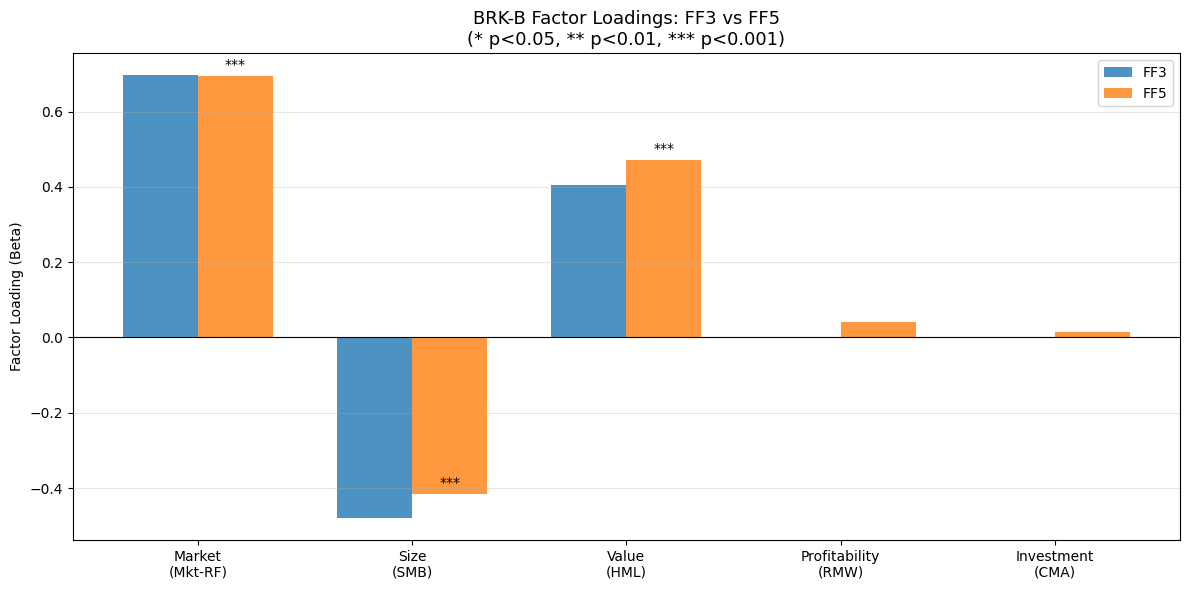

In [14]:
import matplotlib.pyplot as plt
import numpy as np

factors5 = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
labels5 = ['Market\n(Mkt-RF)', 'Size\n(SMB)', 'Value\n(HML)', 'Profitability\n(RMW)', 'Investment\n(CMA)']

coefs3 = [model.params.get(f, np.nan) for f in factors5]
coefs5 = [model5.params[f] for f in factors5]
pvals5 = [model5.pvalues[f] for f in factors5]

x = np.arange(len(factors5))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars3 = ax.bar(x - width/2, coefs3, width, label='FF3', color='#1f77b4', alpha=0.8)
bars5 = ax.bar(x + width/2, coefs5, width, label='FF5', color='#ff7f0e', alpha=0.8)

# Mark significance on FF5 bars
for i, (bar, pval) in enumerate(zip(bars5, pvals5)):
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    if stars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                stars, ha='center', va='bottom', fontsize=10, color='black')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels5)
ax.set_ylabel('Factor Loading (Beta)')
ax.set_title('BRK-B Factor Loadings: FF3 vs FF5\n(* p<0.05, ** p<0.01, *** p<0.001)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## FF5 + BAB + QMJ Regression (AQR Factors)
Adding AQR's factors to isolate the float/leverage/quality channel:
- **BAB**: Betting Against Beta — proxy for Buffett's low-beta leverage strategy (enabled by free float)
- **QMJ**: Quality Minus Junk — captures the safe, profitable, growing companies Buffett selects

If alpha collapses after adding these, it means Buffett's edge is fully explained by systematic exposure to quality and leveraged low-beta — not stock-picking skill.

In [15]:
%pip install --upgrade openpyxl --quiet

Note: you may need to restart the kernel to use updated packages.


In [16]:
def load_aqr_factor(url, sheet, factor_col='USA'):
    """Download an AQR monthly factor Excel file and return the USA monthly series."""
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    df = pd.read_excel(io.BytesIO(r.content), sheet_name=sheet, header=18)
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index('DATE')[factor_col].dropna()
    df = pd.to_numeric(df, errors='coerce').dropna()
    df.index = df.index.normalize()
    df = df * 100  # decimal → percent to match FF data
    return df

bab_url = 'https://images.aqr.com/-/media/AQR/Documents/Insights/Data-Sets/Betting-Against-Beta-Equity-Factors-Monthly.xlsx'
qmj_url = 'https://images.aqr.com/-/media/AQR/Documents/Insights/Data-Sets/Quality-Minus-Junk-Factors-Monthly.xlsx'

bab = load_aqr_factor(bab_url, sheet='BAB Factors')
bab.name = 'BAB'
qmj = load_aqr_factor(qmj_url, sheet='QMJ Factors')
qmj.name = 'QMJ'

print(f'BAB: {len(bab)} months  ({bab.index[0].date()} to {bab.index[-1].date()})')
print(f'QMJ: {len(qmj)} months  ({qmj.index[0].date()} to {qmj.index[-1].date()})')

BAB: 1141 months  (1930-12-31 to 2025-12-31)
QMJ: 822 months  (1957-07-31 to 2025-12-31)


In [17]:
# Normalize all indices to month-start for alignment
def to_month_start(s):
    s = s.copy()
    s.index = s.index.to_period('M').to_timestamp()
    return s

brk_ms   = to_month_start(brk_returns)
ff5_ms   = to_month_start(ff5)
bab_ms   = to_month_start(bab)
qmj_ms   = to_month_start(qmj)

merged7 = pd.concat([brk_ms, ff5_ms, bab_ms, qmj_ms], axis=1, join='inner')
merged7.columns = ['BRK-B', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'BAB', 'QMJ']
merged7['Excess Return'] = merged7['BRK-B'] - merged7['RF']

print(f'Regression period: {merged7.index[0].date()} to {merged7.index[-1].date()}')
print(f'Observations: {len(merged7)}')
merged7.head()

Regression period: 2006-05-01 to 2025-12-01
Observations: 236


,BRK-B,Mkt-RF,SMB,HML,RMW,CMA,RF,BAB,QMJ,Excess Return
2006-05-01,3.963415,-3.56,-2.90,2.38,0.87,1.53,0.43,0.376867,0.897422,3.533415
2006-06-01,-0.847182,-0.34,-0.24,0.85,1.32,-0.13,0.40,0.068395,0.953867,-1.247182
2006-07-01,0.131446,-0.77,-3.60,2.62,1.63,0.84,0.40,2.060916,-0.069187,-0.268554
2006-08-01,5.136201,2.03,0.45,-1.95,-1.81,2.14,0.42,-0.461798,-0.250181,4.716201
2006-09-01,-0.920868,1.84,-1.39,0.06,0.78,0.46,0.41,-0.157162,1.299892,-1.330868


In [18]:
# FF5 + BAB + QMJ regression
X7 = sm.add_constant(merged7[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'BAB', 'QMJ']])
y7 = merged7['Excess Return']

model7 = sm.OLS(y7, X7).fit()
print(model7.summary())

                            OLS Regression Results                            
Dep. Variable:          Excess Return   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     24.80
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           5.18e-25
Time:                        13:36:12   Log-Likelihood:                -654.92
No. Observations:                 236   AIC:                             1326.
Df Residuals:                     228   BIC:                             1354.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2461      0.272      0.905      0.3

In [19]:
# Alpha comparison across all three models
models = {'FF3': model, 'FF5': model5, 'FF5+BAB+QMJ': model7}
all_factors = ['const', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'BAB', 'QMJ']

rows = []
for name, m in models.items():
    row = {'Model': name, 'R²': round(m.rsquared, 4), 'Alpha (ann.)': f"{m.params['const']*12:.2f}%",
           'Alpha p-val': round(m.pvalues['const'], 3)}
    for f in ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'BAB', 'QMJ']:
        if f in m.params:
            sig = '***' if m.pvalues[f] < 0.001 else '**' if m.pvalues[f] < 0.01 else '*' if m.pvalues[f] < 0.05 else ''
            row[f] = f"{m.params[f]:.3f}{sig}"
        else:
            row[f] = '—'
    rows.append(row)

results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.to_string())
print('\n* p<0.05  ** p<0.01  *** p<0.001')

                 R² Alpha (ann.)  Alpha p-val    Mkt-RF        SMB       HML     RMW    CMA     BAB     QMJ
Model                                                                                                      
FF3          0.4263        3.76%        0.232  0.696***  -0.479***  0.405***       —      —       —       —
FF5          0.4177        3.74%        0.248  0.694***  -0.416***  0.471***   0.042  0.015       —       —
FF5+BAB+QMJ  0.4322        2.95%        0.366  0.785***   -0.365**  0.482***  -0.198  0.005  -0.028  0.341*

* p<0.05  ** p<0.01  *** p<0.001


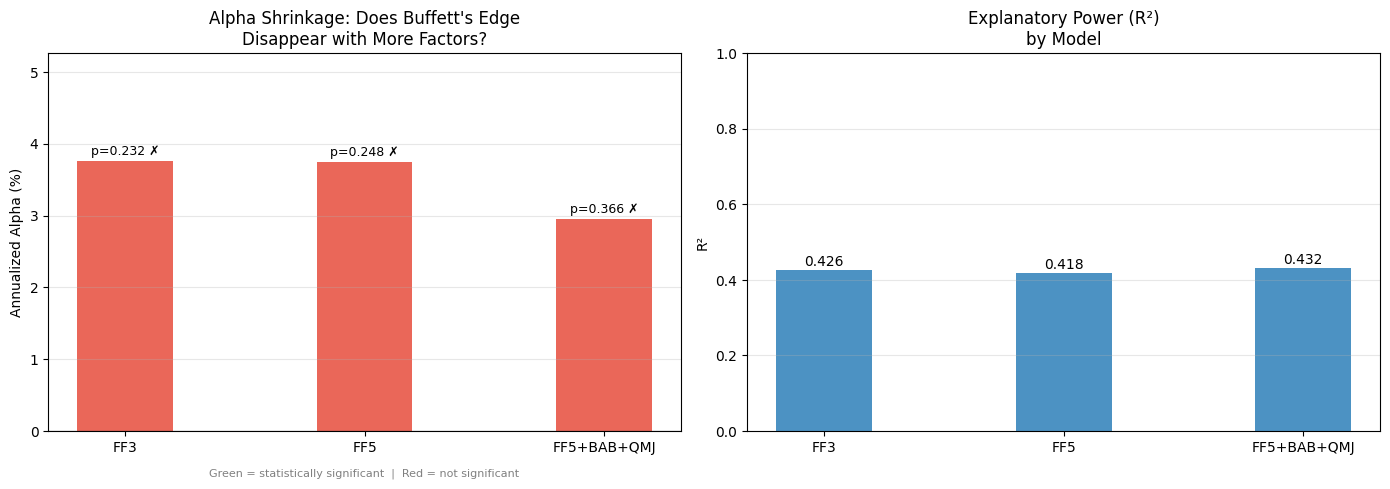

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Alpha shrinkage chart
alpha_vals = [float(r['Alpha (ann.)'].replace('%','')) for r in rows]
alpha_pvals = [r['Alpha p-val'] for r in rows]
model_names = [r['Model'] for r in rows]
colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in alpha_pvals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Alpha bar chart
bars = ax1.bar(model_names, alpha_vals, color=colors, alpha=0.85, width=0.4)
ax1.axhline(0, color='black', linewidth=0.8)
for bar, pval in zip(bars, alpha_pvals):
    label = f'p={pval:.3f}' + (' ✓' if pval < 0.05 else ' ✗')
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             label, ha='center', va='bottom', fontsize=9)
ax1.set_ylabel('Annualized Alpha (%)')
ax1.set_title("Alpha Shrinkage: Does Buffett's Edge\nDisappear with More Factors?", fontsize=12)
ax1.set_ylim(0, max(alpha_vals) * 1.4)
ax1.grid(True, alpha=0.3, axis='y')
ax1.text(0.5, -0.12, 'Green = statistically significant  |  Red = not significant',
         ha='center', transform=ax1.transAxes, fontsize=8, color='gray')

# R² improvement
r2_vals = [m.rsquared for m in models.values()]
ax2.bar(model_names, r2_vals, color='#1f77b4', alpha=0.8, width=0.4)
for bar, val in zip(ax2.patches, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('R²')
ax2.set_title('Explanatory Power (R²)\nby Model', fontsize=12)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()